
# Adam trong tối ưu hóa (Optimization)

Notebook này ghi chú lại kiến thức về **Adam Optimizer** và demo thực tế trên **Titanic dataset**.

Mục tiêu học:

1. Hiểu Adam là gì.
2. Hiểu Adam khác gì so với Gradient Descent / SGD.
3. Biết cách dùng Adam trong PyTorch.
4. Demo train model Logistic Regression trên Titanic data.



## 1. Adam là gì?

**Adam** là viết tắt của **Adaptive Moment Estimation**.

Adam là một thuật toán tối ưu hóa (**optimization algorithm**) dùng để cập nhật trọng số (**weights / parameters**) trong quá trình train model.

Trong Machine Learning và Deep Learning, ta thường muốn giảm **loss function**.

Ví dụ:

$$
\text{Loss càng nhỏ} \Rightarrow \text{model dự đoán càng tốt}
$$

Adam giúp model học bằng cách cập nhật parameters theo hướng làm loss giảm xuống.



## 2. Adam dùng để làm gì?

Khi train model AI, ta cần:

- tính loss
- tính gradient
- cập nhật weights
- lặp lại nhiều lần

Adam giúp bước cập nhật weight trở nên:

- nhanh hơn
- ổn định hơn
- ít cần chỉnh learning rate thủ công hơn
- phù hợp với Deep Learning

Nói đơn giản:

> Adam là một cách update weight thông minh hơn so với Gradient Descent thường.



## 3. Nhắc lại Gradient Descent

Với Gradient Descent thường, công thức update là:

$$
\theta_{new} = \theta_{old} - \alpha \cdot gradient
$$

Trong đó:

- $\theta$: parameter / weight
- $\alpha$: learning rate
- $gradient$: đạo hàm của loss theo parameter

Ý nghĩa:

- gradient cho biết hướng loss tăng nhanh nhất
- ta đi ngược hướng gradient để làm loss giảm



## 4. Adam kết hợp 2 ý tưởng lớn

Adam kết hợp:

### 1. Momentum

Momentum giúp optimizer “nhớ hướng đi trước đó”.

Nếu gradient nhiều lần cùng hướng, Adam sẽ tăng tốc theo hướng đó.

### 2. RMSProp / Adaptive Learning Rate

Adam tự điều chỉnh learning rate riêng cho từng parameter.

Nếu một parameter có gradient quá lớn, Adam sẽ giảm bước đi cho parameter đó.

Nếu một parameter có gradient nhỏ, Adam có thể cho bước đi phù hợp hơn.

Tóm lại:

> Adam vừa nhớ hướng đi, vừa tự chỉnh độ lớn bước đi.



## 5. Công thức Adam

Gọi:

- $g_t$: gradient tại step $t$
- $m_t$: trung bình động của gradient
- $v_t$: trung bình động của gradient bình phương
- $\alpha$: learning rate
- $\beta_1$: hệ số momentum, thường là 0.9
- $\beta_2$: hệ số cho squared gradient, thường là 0.999
- $\epsilon$: số nhỏ để tránh chia cho 0

Công thức:

$$
m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t
$$

$$
v_t = \beta_2 v_{t-1} + (1-\beta_2)g_t^2
$$

Cập nhật parameter:

$$
\theta_t = \theta_{t-1} - \alpha \frac{m_t}{\sqrt{v_t}+\epsilon}
$$

Ý nghĩa:

- $m_t$ giúp nhớ hướng gradient
- $v_t$ giúp điều chỉnh độ lớn bước đi
- Adam dùng cả hai để update weight



## 6. Trực giác dễ hiểu

Ví dụ đi xuống một thung lũng:

### Gradient Descent

Đi đều đều theo độ dốc hiện tại.

Nhược điểm:

- dễ zig-zag
- có thể chậm
- learning rate khó chọn

### Adam

Adam giống như một người đi có kinh nghiệm:

- nhớ hướng đang đi
- nếu đường ổn định thì đi nhanh hơn
- nếu đường dốc mạnh hoặc dao động thì đi cẩn thận hơn

Nói ngắn gọn:

> Gradient Descent = bước đều  
> Adam = bước thông minh



## 7. So sánh nhanh Adam và SGD

| Optimizer | Ý tưởng chính | Ưu điểm | Nhược điểm |
|---|---|---|---|
| SGD | Update theo gradient hiện tại | Đơn giản, ít tốn RAM | Có thể chậm, dễ zig-zag |
| SGD + Momentum | Nhớ hướng gradient cũ | Nhanh hơn SGD | Vẫn cần tuning |
| RMSProp | Adaptive learning rate | Ổn định hơn | Không dùng momentum đầy đủ |
| Adam | Momentum + Adaptive learning rate | Nhanh, phổ biến trong Deep Learning | Có thể generalize kém hơn SGD trong vài bài toán |



## 8. Demo nhỏ: tối ưu hàm $f(x)=x^2$

Mục tiêu: tìm giá trị $x$ làm hàm nhỏ nhất.

Ta biết:

$$
f(x)=x^2
$$

Minimum tại:

$$
x=0
$$

Ta sẽ thử cho optimizer tự tìm về gần 0.


In [1]:

import torch

# Biến cần tối ưu
x = torch.tensor([8.0], requires_grad=True)

# Adam optimizer
optimizer = torch.optim.Adam([x], lr=0.1)

history = []

for step in range(50):
    loss = x ** 2

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    history.append((step + 1, x.item(), loss.item()))

history[:10]


[(1, 7.900000095367432, 64.0),
 (2, 7.800034999847412, 62.40999984741211),
 (3, 7.700128078460693, 60.840545654296875),
 (4, 7.600303649902344, 59.29197311401367),
 (5, 7.500586032867432, 57.76461410522461),
 (6, 7.400999546051025, 56.2587890625),
 (7, 7.301568984985352, 54.77479553222656),
 (8, 7.202319622039795, 53.31290817260742),
 (9, 7.103275775909424, 51.873409271240234),
 (10, 7.004462242126465, 50.45652770996094)]

In [2]:

import pandas as pd

df_history = pd.DataFrame(history, columns=["step", "x", "loss"])
df_history.head(10)


,step,x,loss
0,1,7.900000,64.000000
1,2,7.800035,62.410000
2,3,7.700128,60.840546
3,4,7.600304,59.291973
4,5,7.500586,57.764614
5,6,7.401000,56.258789
6,7,7.301569,54.774796
7,8,7.202320,53.312908
8,9,7.103276,51.873409
9,10,7.004462,50.456528


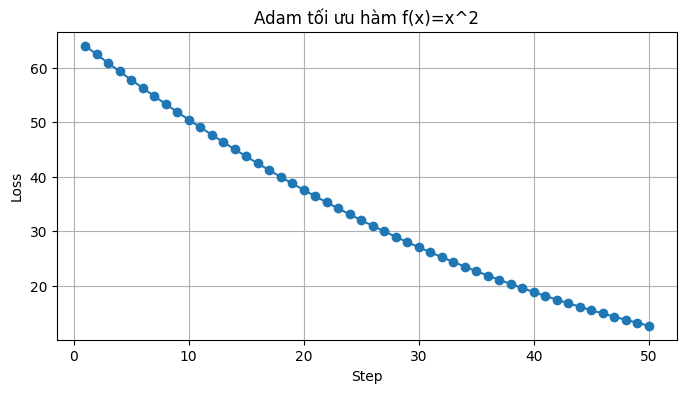

In [3]:

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(df_history["step"], df_history["loss"], marker="o")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Adam tối ưu hàm f(x)=x^2")
plt.grid(True)
plt.show()



## 9. Demo thực tế: Titanic Dataset

Bài toán Titanic:

> Dự đoán một hành khách có sống sót hay không.

Target:

- `Survived = 1`: sống sót
- `Survived = 0`: không sống sót

Ta sẽ dùng model đơn giản:

> Logistic Regression bằng PyTorch

Vì bài toán là binary classification.



## 10. Cài thư viện nếu cần

Nếu máy bạn thiếu thư viện, chạy cell dưới đây.

Nếu đã có rồi thì bỏ qua.


In [ ]:

# Nếu thiếu thư viện thì bỏ comment dòng dưới và chạy:
# !pip install pandas numpy matplotlib seaborn scikit-learn torch



## 11. Load Titanic Dataset

Ta sẽ dùng dataset Titanic có sẵn trong thư viện `seaborn`.

Nếu không load được bằng seaborn, bạn có thể thay bằng file CSV Titanic của Kaggle.


In [4]:

import pandas as pd
import numpy as np

titanic = pd.read_csv("../data/titanic/Titanic-Dataset.csv")

titanic.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:

titanic.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB



## 12. Chọn features đơn giản

Ta chọn vài biến dễ hiểu:

- `pclass`: hạng vé
- `sex`: giới tính
- `age`: tuổi
- `sibsp`: số anh chị em / vợ chồng đi cùng
- `parch`: số cha mẹ / con cái đi cùng
- `fare`: giá vé
- `embarked`: cảng lên tàu

Target là:

- `survived`


In [6]:

features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
target = "Survived"

data = titanic[features + [target]].copy()

data.head()


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,1
3,1,female,35.0,1,0,53.1000,S,1
4,3,male,35.0,0,0,8.0500,S,0



## 13. Xử lý missing values

Dataset Titanic có một số giá trị thiếu, đặc biệt là `age` và `embarked`.

Cách xử lý đơn giản:

- `age`: điền bằng median
- `fare`: điền bằng median
- `embarked`: điền bằng mode


In [7]:

data["Age"] = data["Age"].fillna(data["Age"].median())
data["Fare"] = data["Fare"].fillna(data["Fare"].median())
data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])

data.isna().sum()


Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
Survived    0
dtype: int64


## 14. Encode categorical variables

Model không hiểu chữ như `male`, `female`, `S`, `C`, `Q`.

Ta cần chuyển thành số bằng One-Hot Encoding.


In [8]:

data_encoded = pd.get_dummies(data, columns=["Sex", "Embarked"], drop_first=True)

data_encoded.head()


,Pclass,Age,SibSp,Parch,Fare,Survived,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,0,True,False,True
1,1,38.0,1,0,71.2833,1,False,False,False
2,3,26.0,0,0,7.9250,1,False,False,True
3,1,35.0,1,0,53.1000,1,False,False,True
4,3,35.0,0,0,8.0500,0,True,False,True



## 15. Train-test split và chuẩn hóa dữ liệu

Ta chia dữ liệu thành:

- training set: dùng để train model
- test set: dùng để kiểm tra model

Sau đó chuẩn hóa features bằng `StandardScaler`.

Chuẩn hóa giúp optimizer học ổn định hơn.


In [9]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = data_encoded.drop(columns=[target]).values.astype(np.float32)
y = data_encoded[target].values.astype(np.float32).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

X_train_scaled.shape, X_test_scaled.shape


((712, 8), (179, 8))


## 16. Chuyển dữ liệu sang Tensor

PyTorch làm việc với tensor, nên ta chuyển NumPy array sang tensor.


In [10]:

X_train_tensor = torch.tensor(X_train_scaled)
y_train_tensor = torch.tensor(y_train)

X_test_tensor = torch.tensor(X_test_scaled)
y_test_tensor = torch.tensor(y_test)

X_train_tensor.shape, y_train_tensor.shape


(torch.Size([712, 8]), torch.Size([712, 1]))


## 17. Tạo model Logistic Regression bằng PyTorch

Vì bài toán binary classification, model sẽ output một giá trị logit.

Sau đó ta dùng `BCEWithLogitsLoss`.

Lưu ý:

- Không cần thêm sigmoid trong model
- Vì `BCEWithLogitsLoss` đã xử lý sigmoid bên trong


In [11]:

import torch.nn as nn

class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x)

input_dim = X_train_tensor.shape[1]
model = LogisticRegressionModel(input_dim)

model


LogisticRegressionModel(
  (linear): Linear(in_features=8, out_features=1, bias=True)
)


## 18. Train model với Adam

Ở đây ta dùng:

```python
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
```

Ý nghĩa:

- `model.parameters()` là các weights cần update
- `lr=0.01` là learning rate
- Adam sẽ tự điều chỉnh update cho từng weight


In [12]:

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

epochs = 300
train_losses = []

for epoch in range(epochs):
    model.train()

    logits = model(X_train_tensor)
    loss = criterion(logits, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss = {loss.item():.4f}")


Epoch 50/300, Loss = 0.5376
Epoch 100/300, Loss = 0.4742
Epoch 150/300, Loss = 0.4522
Epoch 200/300, Loss = 0.4427
Epoch 250/300, Loss = 0.4388
Epoch 300/300, Loss = 0.4372



## 19. Vẽ loss curve

Nếu loss giảm dần, model đang học.


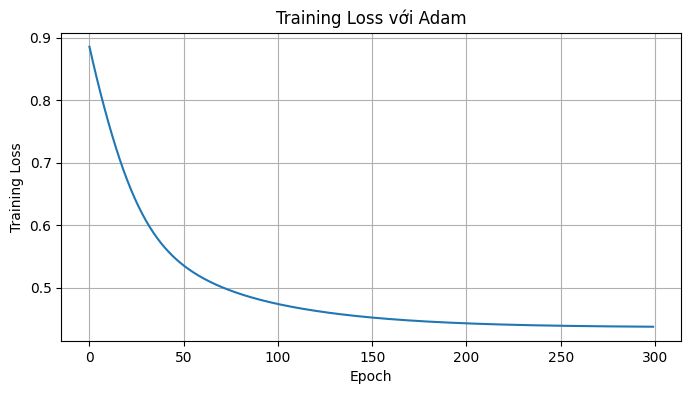

In [13]:

plt.figure(figsize=(8, 4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss với Adam")
plt.grid(True)
plt.show()



## 20. Đánh giá model trên test set

Ta sẽ:

1. lấy output logits
2. chuyển sang probability bằng sigmoid
3. nếu probability >= 0.5 thì dự đoán sống sót
4. tính accuracy


In [14]:

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model.eval()

with torch.no_grad():
    test_logits = model(X_test_tensor)
    test_probs = torch.sigmoid(test_logits)
    test_preds = (test_probs >= 0.5).float()

accuracy = accuracy_score(y_test_tensor.numpy(), test_preds.numpy())

print(f"Test Accuracy: {accuracy:.4f}")


Test Accuracy: 0.7989


In [15]:

print(confusion_matrix(y_test_tensor.numpy(), test_preds.numpy()))
print(classification_report(y_test_tensor.numpy(), test_preds.numpy()))


[[97 13]
 [23 46]]
              precision    recall  f1-score   support

         0.0       0.81      0.88      0.84       110
         1.0       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179




## 21. So sánh nhanh Adam với SGD

Bây giờ ta train lại cùng model nhưng dùng SGD.

Lưu ý:

- cùng dataset
- cùng model type
- khác optimizer


In [16]:

def train_with_optimizer(optimizer_name="adam", lr=0.01, epochs=300):
    model_temp = LogisticRegressionModel(input_dim)
    criterion = nn.BCEWithLogitsLoss()

    if optimizer_name.lower() == "adam":
        optimizer_temp = torch.optim.Adam(model_temp.parameters(), lr=lr)
    elif optimizer_name.lower() == "sgd":
        optimizer_temp = torch.optim.SGD(model_temp.parameters(), lr=lr)
    else:
        raise ValueError("optimizer_name chỉ nhận 'adam' hoặc 'sgd'")

    losses = []

    for epoch in range(epochs):
        model_temp.train()

        logits = model_temp(X_train_tensor)
        loss = criterion(logits, y_train_tensor)

        optimizer_temp.zero_grad()
        loss.backward()
        optimizer_temp.step()

        losses.append(loss.item())

    model_temp.eval()
    with torch.no_grad():
        test_logits = model_temp(X_test_tensor)
        test_probs = torch.sigmoid(test_logits)
        test_preds = (test_probs >= 0.5).float()
        acc = accuracy_score(y_test_tensor.numpy(), test_preds.numpy())

    return losses, acc

adam_losses, adam_acc = train_with_optimizer("adam", lr=0.01, epochs=300)
sgd_losses, sgd_acc = train_with_optimizer("sgd", lr=0.01, epochs=300)

print(f"Adam Accuracy: {adam_acc:.4f}")
print(f"SGD Accuracy:  {sgd_acc:.4f}")


Adam Accuracy: 0.8045
SGD Accuracy:  0.7765


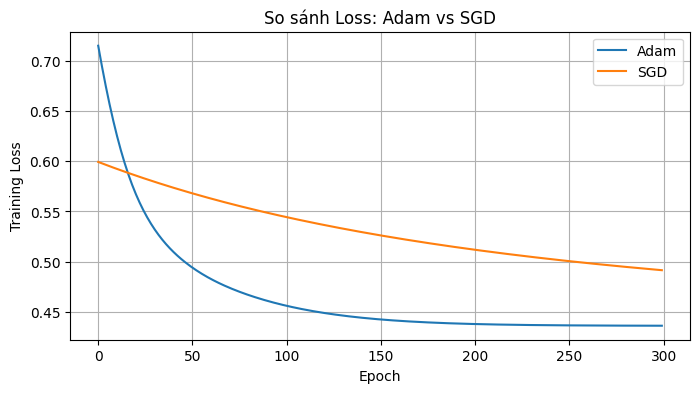

In [17]:

plt.figure(figsize=(8, 4))
plt.plot(adam_losses, label="Adam")
plt.plot(sgd_losses, label="SGD")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("So sánh Loss: Adam vs SGD")
plt.legend()
plt.grid(True)
plt.show()



## 22. Cách đọc kết quả

Nếu Adam loss giảm nhanh hơn SGD, điều đó thể hiện Adam học nhanh hơn trong bài toán này.

Tuy nhiên, không phải lúc nào Adam cũng thắng tuyệt đối.

Thực tế:

- Adam thường tốt để bắt đầu train nhanh
- SGD đôi khi cho generalization tốt hơn ở một số bài toán lớn
- Trong Deep Learning hiện đại, Adam / AdamW rất phổ biến



## 23. Tổng kết

Adam là optimizer rất quan trọng trong Machine Learning và Deep Learning.

Cần nhớ:

1. Adam vẫn dựa trên Gradient Descent.
2. Adam dùng gradient để cập nhật weights.
3. Adam có thêm Momentum để nhớ hướng đi.
4. Adam có Adaptive Learning Rate để tự điều chỉnh bước đi.
5. Adam thường train nhanh và ổn định.
6. Trong PyTorch, dùng Adam rất đơn giản:

```python
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
```

Điểm quan trọng nhất:

> Adam không thay đổi mục tiêu tối ưu hóa. Nó chỉ làm quá trình đi tìm minimum thông minh hơn.
